# Optimizing a stellarator geometry from GVEC

This notebook links to pyGVEC directly by default. It constructs or accepts an in-memory `gvec.State`, then passes that live object to `GvecGeometryProvider`; no exported geometry file is involved. Synthetic geometry remains an explicit fallback mode. Placeholder pieces are identified explicitly.

> Current capability: the GVEC adapter is an evaluation boundary and is marked non-differentiable. Geometry derivatives should therefore be taken in an outer finite-difference or derivative-free loop.

## Division of responsibility

`GVEC parameter/state` → equilibrium and PEST evaluation → `GvecGeometryProvider` → physical arrays (`B`, gradients, curvature, $\iota$, shear) → `GeometryResult` → normalized internal coefficients → linear gyrokinetic residual/time evolution → growth, frequency, mode structure, quasilinear proxy → scalar objective.

GVEC supplies a global equilibrium; `jax_fluxtube_gk` samples one local field line and predicts reduced kinetic stability there. A realistic stellarator objective usually aggregates several radii, field-line labels $\alpha$, and $k_y$ values, while adding equilibrium and engineering constraints outside the GK solver.

In [1]:
import os
from pathlib import Path
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jax_fluxtube_gk import (
    DesignObjectiveSpec, FourierGridSpec, GeometryRequest, GvecGeometryProvider,
    OptimizationKnobs, SingleSurfaceOptimizationConfig, SyntheticGeometryProvider,
    VelocityGridSpec, assert_fixed_optimization_topology, build_fourier_grid,
    build_mode_connectivity, build_optimization_topology_contract, build_velocity_grid,
    design_objective, internal_geometry_from_result, k_perp_squared, resolve_geometry,
)

jax.config.update("jax_enable_x64", True)

ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
GEOMETRY_SOURCE = "provider"  # provider | synthetic
GVEC_PARAMETER_FILE = os.environ.get("GVEC_PARAMETER_FILE")
GVEC_STATE_FILE = os.environ.get("GVEC_STATE_FILE")
GVEC_STATE = None  # Or assign an already constructed gvec.State here.

In [2]:
def gvec_boundary_xyz(state, n_theta=60, n_zeta=200, rho=1.0):
    """Evaluate the GVEC state's Cartesian position on a boundary (theta, zeta) grid
    and return (X, Y, Z) surface grids of shape (n_theta, n_zeta)."""
    theta = np.linspace(0.0, 2 * np.pi, n_theta, endpoint=True)
    zeta = np.linspace(0.0, 2 * np.pi, n_zeta, endpoint=True)
    data = state.evaluate("pos", rho=np.asarray([rho]), theta=theta, zeta=zeta)
    pos = np.asarray(data["pos"].values)[:, 0, :, :]
    return pos[0], pos[1], pos[2]


def plot_boundary_surface(ax, X, Y, Z, **kwargs):
    """Render a stellarator boundary surface with a physically equal-aspect, angled view."""
    ax.plot_surface(X, Y, Z, rstride=1, cstride=1, linewidth=0, antialiased=True, **kwargs)
    span = max(X.max() - X.min(), Y.max() - Y.min(), Z.max() - Z.min())
    ax.set_box_aspect(((X.max() - X.min()) / span, (Y.max() - Y.min()) / span, (Z.max() - Z.min()) / span))
    ax.view_init(elev=35, azim=45)
    ax.set_axis_off()

In [3]:
request = GeometryRequest(
    configuration="gvec-design", radial_value=0.8, alpha=0.0, n_z=32,
    z_min=-np.pi, z_max=np.pi, field_periods=1.0,
)
if GEOMETRY_SOURCE == "provider":
    state = GVEC_STATE
    if state is None:
        if not GVEC_PARAMETER_FILE:
            raise RuntimeError(
                "Set GVEC_PARAMETER_FILE or assign an in-memory GVEC_STATE. "
                "The parameter file configures a live GVEC solve; it is not geometry data."
            )
        import gvec

        state = gvec.State(GVEC_PARAMETER_FILE, GVEC_STATE_FILE)
    provider = GvecGeometryProvider(state=state, revision="record-your-revision")
elif GEOMETRY_SOURCE == "synthetic":
    provider = SyntheticGeometryProvider(magnetic_field_amplitude=0.16, iota=0.85, shear=0.25, nfp=5)
else:
    raise ValueError("GEOMETRY_SOURCE must be 'provider' or 'synthetic'")

geometry_result = resolve_geometry(provider, request)
parallel = geometry_result.parallel_grid
geometry = internal_geometry_from_result(geometry_result)
metadata = geometry_result.metadata
print(f"provider={metadata.provenance.provider!r}, differentiable={metadata.differentiable}")
print(f"source={metadata.provenance.source}")

provider='gvec', differentiable=False
source=in-memory GVEC state


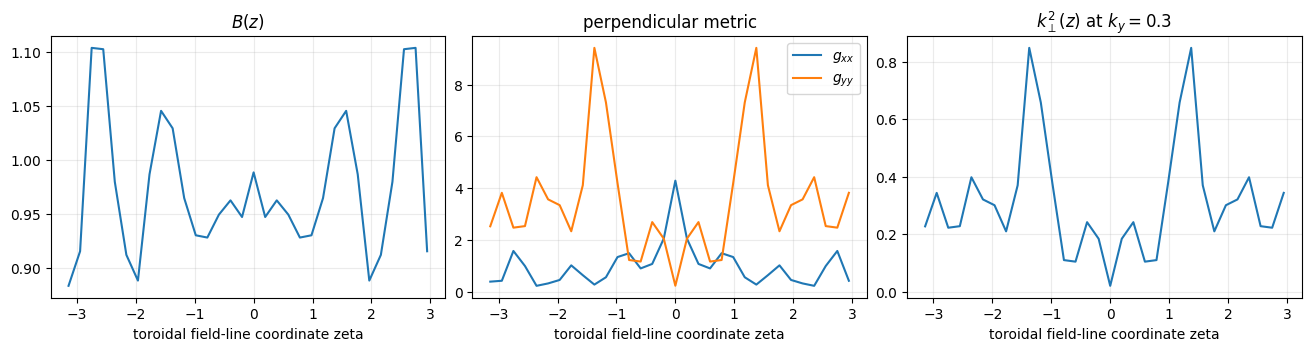

In [4]:
fourier = build_fourier_grid(FourierGridSpec(n_kx=1, n_ky=1, kx_max=0.0, ky_values=(0.3,)))
kp2 = np.asarray(k_perp_squared(geometry, fourier)).squeeze()
z = np.asarray(parallel.z)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), constrained_layout=True)
axes[0].plot(z, np.asarray(geometry.B))
axes[0].set_title(r"$B(z)$")
axes[1].plot(z, np.asarray(geometry.g_xx), label=r"$g_{xx}$")
axes[1].plot(z, np.asarray(geometry.g_yy), label=r"$g_{yy}$")
axes[1].legend()
axes[1].set_title("perpendicular metric")
axes[2].plot(z, kp2)
axes[2].set_title(r"$k_\perp^2(z)$ at $k_y=0.3$")
for ax in axes:
    ax.set_xlabel("toroidal field-line coordinate zeta")
    ax.grid(alpha=0.25)
plt.show()

## Trace one reduced GK objective

The state has axes `(v_parallel, mu, z, kx, ky)`. The linear residual combines parallel streaming, magnetic drifts, profile-gradient drive, field response, and the configured collision/closure pieces. After short time evolution, diagnostics turn the mode amplitude and phase into growth and frequency. Here the resolution is intentionally tiny so the notebook tests integration, not convergence.

In [5]:
velocity = build_velocity_grid(VelocityGridSpec(n_vpar=2, n_mu=2, vpar_max=1.5, mu_max=1.0))
connectivity = build_mode_connectivity(fourier)
shape = (velocity.vpar.size, velocity.mu.size, parallel.z.size, 1, 1)
index = jnp.arange(np.prod(shape), dtype=jnp.float64).reshape(shape)
initial_state = 1e-2 * (jnp.cos(index / 7.0) + 1j * jnp.sin(index / 11.0))
spec = DesignObjectiveSpec(selected_ky=0, growth_weight=1.0)
config = SingleSurfaceOptimizationConfig(
    geometry_model="precomputed", dt=0.005, n_steps=2, selected_ky=0,
    objective_kind="selected_growth", store_history=False,
)

def gk_objective(local_geometry, temperature_gradient=2.1):
    return design_objective(
        OptimizationKnobs(density_gradient=0.8, temperature_gradient=temperature_gradient),
        velocity, parallel, fourier, initial_state, spec, connectivity=connectivity,
        config=config, geometry=local_geometry,
    )

result = gk_objective(geometry)
profile_grad = jax.grad(lambda a: gk_objective(geometry, a).scalar_objective)(jnp.array(2.1))
print(f"objective={float(result.scalar_objective): .6e}")
print(f"growth={float(result.selected_growth_rate): .6e}, frequency={float(result.selected_frequency): .6e}")
print(f"fixed-geometry d objective / d(R/L_T)={float(profile_grad): .6e}")

objective= 1.789551e-01
growth= 1.789551e-01, frequency= 1.524648e-02
fixed-geometry d objective / d(R/L_T)= 1.819982e-06


## Geometry loop for GVEC

For a real design vector $p$, construct a fresh GVEC state for $p$, evaluate the same fixed set of `(rho, alpha, ky)` samples, and aggregate their GK objectives. Central differences require `2N+1` equilibrium/GK evaluations for $N$ parameters; derivative-free methods can be preferable when equilibrium convergence is noisy. Always record convergence and constraint residuals, and penalize/reject failed equilibria.

The executable loop below is an **interface surrogate**. Its parameter changes synthetic magnetic shear and its cost is a cheap geometric proxy. Replace `surrogate_cost` by fresh `GvecGeometryProvider(...)` and `gk_objective(...)` calls for a real loop.

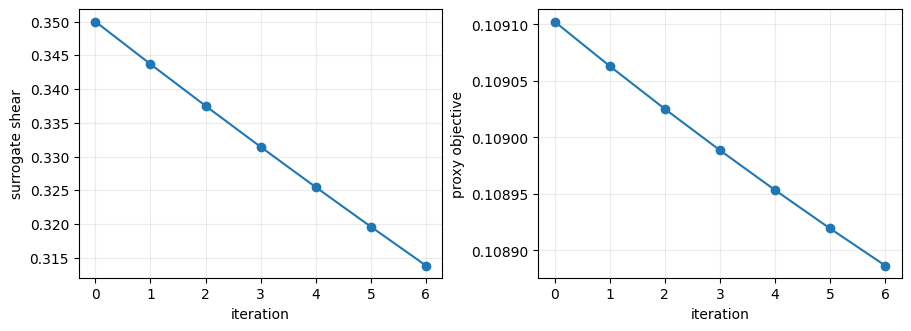

In [6]:
def surrogate_cost(shear):
    candidate = resolve_geometry(
        SyntheticGeometryProvider(magnetic_field_amplitude=0.16, iota=0.85, shear=shear, nfp=5), request
    )
    geom = internal_geometry_from_result(candidate)
    return float(jnp.mean(k_perp_squared(geom, fourier)))

parameter, h, rate = 0.35, 1e-3, 1.0
history = []
for iteration in range(7):
    value = surrogate_cost(parameter)
    gradient = (surrogate_cost(parameter + h) - surrogate_cost(parameter - h)) / (2 * h)
    history.append((iteration, parameter, value, gradient))
    parameter = float(np.clip(parameter - rate * gradient, -1.0, 1.0))
history = np.asarray(history)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), constrained_layout=True)
axes[0].plot(history[:, 0], history[:, 1], "o-")
axes[0].set_ylabel("surrogate shear")
axes[1].plot(history[:, 0], history[:, 2], "o-")
axes[1].set_ylabel("proxy objective")
for ax in axes:
    ax.set_xlabel("iteration")
    ax.grid(alpha=0.25)
plt.show()

WARNING /Users/mohsensadr/Codes/GitHub/fusion/gvec/python/gvec/core/run.py:883: UserWarning: Force tolerance was not reached! |force|: 2.28e-03, minimize_tol: 1.00e-08
  warnings.warn(



WARNING /Users/mohsensadr/Codes/GitHub/fusion/gvec/python/gvec/core/run.py:883: UserWarning: Force tolerance was not reached! |force|: 2.28e-03, minimize_tol: 1.00e-08
  warnings.warn(



WARNING /Users/mohsensadr/Codes/GitHub/fusion/gvec/python/gvec/core/run.py:883: UserWarning: Force tolerance was not reached! |force|: 2.28e-03, minimize_tol: 1.00e-08
  warnings.warn(



iteration 0: scale=1.000000 objective= 2.741767e-01 max_force=2.284e-03 sensitivity=-7.633e-03


WARNING /Users/mohsensadr/Codes/GitHub/fusion/gvec/python/gvec/core/run.py:883: UserWarning: Force tolerance was not reached! |force|: 2.28e-03, minimize_tol: 1.00e-08
  warnings.warn(



...

WARNING /Users/mohsensadr/Codes/GitHub/fusion/gvec/python/gvec/core/run.py:883: UserWarning: Force tolerance was not reached! |force|: 2.28e-03, minimize_tol: 1.00e-08
  warnings.warn(



WARNING /Users/mohsensadr/Codes/GitHub/fusion/gvec/python/gvec/core/run.py:883: UserWarning: Force tolerance was not reached! |force|: 2.28e-03, minimize_tol: 1.00e-08
  warnings.warn(



WARNING /Users/mohsensadr/Codes/GitHub/fusion/gvec/python/gvec/core/run.py:883: UserWarning: Force tolerance was not reached! |force|: 2.28e-03, minimize_tol: 1.00e-08
  warnings.warn(



completed 48 iterations (stopped after 908s (wall-clock budget 900s))


saved /Users/mohsensadr/Codes/GitHub/fusion/JAXFluxTubeGK/figures/gvec_boundary_evolution.png


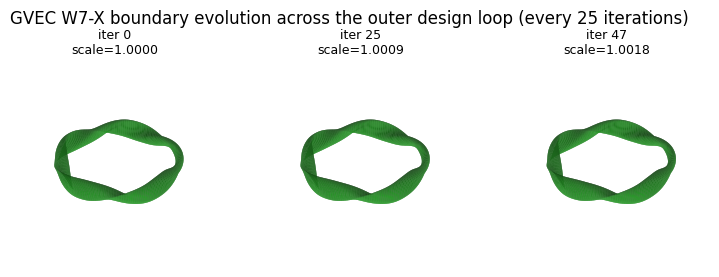

saved /Users/mohsensadr/Codes/GitHub/fusion/JAXFluxTubeGK/figures/gvec_initial_live_design_scan.png


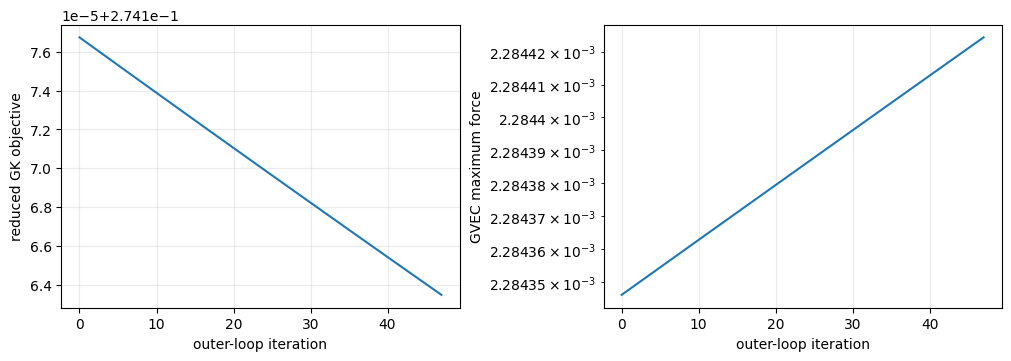

[{'scale': 1.0, 'coefficient': -0.0121, 'objective': 0.27417673591205727, 'growth_rate': 0.27417673591205727, 'frequency': -0.049803928131557526, 'max_force': 0.00228434621621445, 'iterations': 100, 'provider': 'gvec', 'iteration': 0, 'requested_scale': 1.0, 'sensitivity': -0.007633323129141523}, {'scale': 1.0000381666156457, 'coefficient': -0.012100461816049313, 'objective': 0.27417644980118894, 'growth_rate': 0.27417644980118894, 'frequency': -0.049803626035333726, 'max_force': 0.00228434788466305, 'iterations': 100, 'provider': 'gvec', 'iteration': 1, 'requested_scale': 1.0000381666156457, 'sensitivity': -0.007630268091789135}, {'scale': 1.0000763179561047, 'coefficient': -0.012100923447268867, 'objective': 0.27417616387870325, 'growth_rate': 0.27417616387870325, 'frequency': -0.04980332386997698, 'max_force': 0.00228434955242601, 'iterations': 100, 'provider': 'gvec', 'iteration': 2, 'requested_scale': 1.0000763179561047, 'sensitivity': -0.007627213990270933}] ... [{'scale': 1.0017

In [7]:
reference_topology = build_optimization_topology_contract(
    velocity, parallel, fourier, connectivity=connectivity,
    geometry_metadata=geometry_result.metadata,
)

def evaluate_live_gvec_design(boundary_scale, mode=(1, 1), maxiter=100):
    """Scale one GVEC boundary coefficient, solve in scratch, and evaluate GK."""
    import copy
    import tempfile
    import gvec

    if GVEC_PARAMETER_FILE is None:
        raise RuntimeError("A GVEC parameterization is required for boundary optimization")
    base_state = gvec.State(GVEC_PARAMETER_FILE, GVEC_STATE_FILE)
    parameters = copy.deepcopy(base_state.parameters)
    parameters["ProjectName"] = f"JAX_GK_SCALE_{boundary_scale:.6f}"
    reference_coefficient = float(parameters["X1_b_cos"][mode])
    parameters["X1_b_cos"][mode] = boundary_scale * reference_coefficient
    parameters["MaxIter"] = maxiter
    with tempfile.TemporaryDirectory(prefix="jax-fluxtube-gk-gvec-") as scratch:
        run = gvec.run(
            parameters, runpath=Path(scratch), quiet=True, loglevel="WARNING"
        )
        candidate_result = resolve_geometry(
            GvecGeometryProvider(state=run.state, revision="record-your-revision"),
            request,
        )
        candidate_topology = build_optimization_topology_contract(
            velocity, candidate_result.parallel_grid, fourier,
            connectivity=connectivity, geometry_metadata=candidate_result.metadata,
        )
        assert_fixed_optimization_topology(reference_topology, candidate_topology)
        objective = gk_objective(internal_geometry_from_result(candidate_result))
        # Evaluate the boundary surface here, while the GVEC state (and its scratch
        # runpath) is still alive, rather than returning the state itself.
        boundary_xyz = gvec_boundary_xyz(run.state)
    return {
        "scale": float(boundary_scale),
        "coefficient": float(parameters["X1_b_cos"][mode]),
        "objective": float(objective.scalar_objective),
        "growth_rate": float(objective.selected_growth_rate),
        "frequency": float(objective.selected_frequency),
        "max_force": float(run.max_force),
        "iterations": int(run.GVEC_iter_used),
        "provider": candidate_result.metadata.provenance.provider,
        "boundary_xyz": boundary_xyz,
    }

if GEOMETRY_SOURCE == "provider" and GVEC_PARAMETER_FILE:
    # Outer-loop hill-climb: at each iteration, take a real 3-point central-difference
    # sensitivity through fresh GVEC solves (as above), step the boundary scale, and
    # record the resulting real 3D boundary shape. GVEC's solves here are bounded at
    # maxiter=100 for runtime, so intermediate equilibria are diagnostic, not
    # force-converged -- the notebook's own force panel below makes that explicit.
    # The loop targets N_ITERATIONS_TARGET steps but fails closed: a non-finite
    # objective, a raised exception (e.g. a GVEC solve that stops converging as
    # the boundary is pushed further), or exceeding the wall-clock budget stops
    # it early with whatever iterations already succeeded.
    import time

    N_ITERATIONS_TARGET = 100
    FRAME_STRIDE = 25
    MAX_WALL_SECONDS = 900.0
    relative_step = 0.005
    learning_rate = 0.005
    scale_bounds = (0.95, 1.05)
    scale = 1.0
    history = []
    boundary_frames = []
    last_frame = None
    start_time = time.monotonic()
    stop_reason = "completed all requested iterations"
    for iteration in range(N_ITERATIONS_TARGET):
        elapsed = time.monotonic() - start_time
        if elapsed > MAX_WALL_SECONDS:
            stop_reason = f"stopped after {elapsed:.0f}s (wall-clock budget {MAX_WALL_SECONDS:.0f}s)"
            break
        design_scales = scale + scale * np.array([-relative_step, 0.0, relative_step])
        try:
            live_design = [evaluate_live_gvec_design(s) for s in design_scales]
            objectives = np.array([row["objective"] for row in live_design])
            if not np.all(np.isfinite(objectives)):
                raise FloatingPointError("non-finite objective from GVEC/GK evaluation")
        except Exception as error:  # noqa: BLE001 - fail closed, keep prior iterations
            stop_reason = f"stopped at iteration {iteration} after solver error: {error!r}"
            print(stop_reason)
            break
        sensitivity = float(
            (objectives[2] - objectives[0]) / (design_scales[2] - design_scales[0])
        )
        center = live_design[1]
        history.append(
            {key: value for key, value in center.items() if key != "boundary_xyz"}
            | {"iteration": iteration, "requested_scale": scale, "sensitivity": sensitivity}
        )
        # Cheap post-processing of the already-solved center state, not a new solve.
        last_frame = (iteration, scale, center["boundary_xyz"])
        if iteration % FRAME_STRIDE == 0:
            boundary_frames.append(last_frame)
            print(
                f"iteration {iteration}: scale={scale:.6f} objective={center['objective']: .6e} "
                f"max_force={center['max_force']:.3e} sensitivity={sensitivity: .3e}"
            )
        scale = float(np.clip(scale - learning_rate * sensitivity, *scale_bounds))
    n_completed = len(history)
    print(f"completed {n_completed} iterations ({stop_reason})")
    if last_frame is not None and (not boundary_frames or boundary_frames[-1][0] != last_frame[0]):
        boundary_frames.append(last_frame)

    n_frames = len(boundary_frames)
    fig = plt.figure(figsize=(3.0 * n_frames, 3.2))
    for column, (iteration, iter_scale, (X, Y, Z)) in enumerate(boundary_frames):
        ax = fig.add_subplot(1, n_frames, column + 1, projection="3d")
        plot_boundary_surface(ax, X, Y, Z, color="tab:green", alpha=0.95)
        ax.set_title(f"iter {iteration}\nscale={iter_scale:.4f}", fontsize=9)
    fig.suptitle(f"GVEC W7-X boundary evolution across the outer design loop (every {FRAME_STRIDE} iterations)")
    boundary_figure_path = ROOT / "figures/gvec_boundary_evolution.png"
    fig.savefig(boundary_figure_path, dpi=150, bbox_inches="tight")
    print(f"saved {boundary_figure_path}")
    plt.show()

    iterations = np.array([row["iteration"] for row in history])
    scales = np.array([row["scale"] for row in history])
    objectives = np.array([row["objective"] for row in history])
    forces = np.array([row["max_force"] for row in history])
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
    axes[0].plot(iterations, objectives, "-")
    axes[0].set_ylabel("reduced GK objective")
    axes[1].plot(iterations, forces, "-")
    axes[1].set_yscale("log")
    axes[1].set_ylabel("GVEC maximum force")
    for ax in axes:
        ax.set_xlabel("outer-loop iteration")
        ax.grid(alpha=0.25)
    figure_path = ROOT / "figures/gvec_initial_live_design_scan.png"
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
    print(f"saved {figure_path}")
    plt.show()
    print(history[:3], "...", history[-3:])
else:
    print("Set GVEC_PARAMETER_FILE and select provider mode to run the live design scan.")

### Production checklist

Use a small symmetry-preserving parameter set first; freeze numerical topology; aggregate several flux tubes rather than trusting one; store provider version/revision and normalization; keep generated states in external scratch; audit finite-difference step size; and re-run accepted candidates with converged equilibrium and GK resolution. The force panel below shows why the initial low-resolution points are diagnostic rather than acceptable optimized equilibria.

![Initial live GVEC design sensitivity and force residual](../figures/gvec_initial_live_design_scan.png)

The real 3D boundary below is evaluated directly from each iteration's solved GVEC state (`state.evaluate("pos", ...)` at `rho=1`).

![GVEC boundary evolution across the outer design loop](../figures/gvec_boundary_evolution.png)